# Analisi statistica

In [70]:
# importo le librerie utili
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importo il file csv
df = pd.read_csv('df_finale.csv',sep=';',keep_default_na=False)

In [56]:
# inizio a vedere le principali metriche per farmi un'idea sui dati che ho
df.describe().round(2)

,Codice comune,Anno,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
count,190900.00,190900.00,190900.00,190900.00,190900.00,190900.00,190900.0
mean,44492.22,2012.34,37.70,7423.75,35.10,0.53,25.0
std,32071.71,6.86,50.40,41024.15,338.34,2.79,257.7
min,1001.00,2001.00,0.12,28.00,0.00,0.00,0.0
25%,16137.00,2006.00,11.33,1032.00,1.00,0.00,1.0
50%,38009.00,2012.00,22.13,2442.00,5.00,0.00,3.0
75%,71048.00,2018.00,43.81,6115.25,18.00,0.00,12.0
max,111107.00,2024.00,1288.19,2820219.00,30254.00,363.00,23135.0


# EDA
Ho deciso di analizzare nello specifico le metriche legate agli incidenti perchè sono quelle che mi aiuteranno a rispondere alle richieste del compito (dove investire per la sicurezza stradale).
i restanti dati legati ai comuni, superfice anno e popolazione residente li userò a supporto dei valori che andrò ad usare/presentare

## analisi dei valori max 

quelli che a un primo momento mi potevano sembrare degli outlier ( i max), per via della differenza tra valore max e le altre metriche, alla fine ho riscontrato che tutti questi valori sono legati a Roma.
Essendo Roma la città con la popolazione più densa ha senso che questi valori siano concentrati su questo Comune in particolare.

In [99]:
# verifico con un filtro a cosa fa riferimnento il volore più alto dei feriti
df[df['Feriti'] == df['Feriti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [98]:
# verifico con un filtro a cosa fa riferimnento il volore più alto degli incidenti

df[df['Incidenti'] == df['Incidenti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116081,58091,Roma,2004,Annuale,1287.3371,2566690,30254,260,23135


In [ ]:
# verifico con un filtro a cosa fa riferimnento il volore più alto degli abitanti/resiendenti
df[df['Popolazione residente'] == df['Popolazione residente'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116095,58091,Roma,2018,Annuale,1287.3895,2820219,15551,148,11995


In [ ]:
# verifico con un filtro a cosa fa riferimnento il volore più alto dei morti
df[df['Morti'] == df['Morti'].max()]

,Codice comune,Comune,Anno,Frequenza,Superficie (Kmq),Popolazione residente,Feriti,Morti,Incidenti
116079,58091,Roma,2002,Annuale,1287.3371,2544815,26696,363,21330


## analisi della distruibuzione dati

Ho deciso di analizzare i dati inerenti agli incidenti con il boxplot e istogrammi, la differenza tra la media e mediana (nel .describe()) mi suggerisce la presenza di outliers che trasciano la media verso valori più alti indicando quindi una distribuzione dei valori non lineare (skewness positiva) perchè appunto abbiamo valori (bassi) legati a piccoli comuni (che sono la maggioranza) e valori (alti) legati a grandi comuni (che sono la minoranza).

### Boxplot

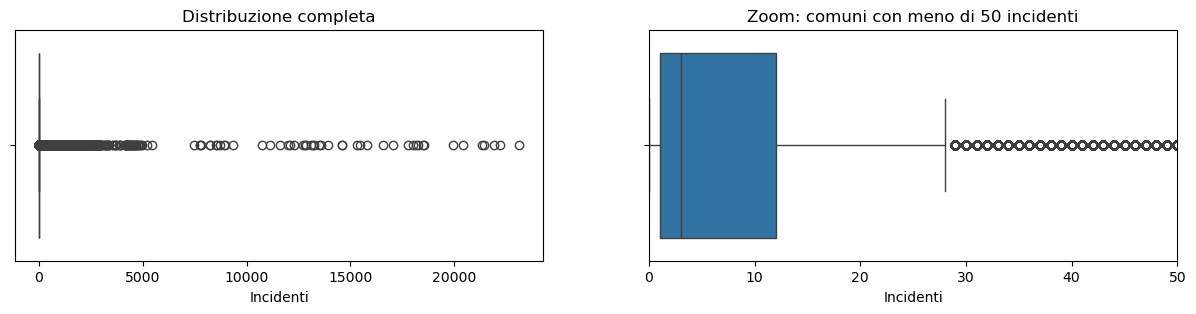

dal boxplot si vede come il 50% dei valori rientra in un range che va da [1.] a [12.] incidenti, (IQR range). I baffi si estendono fino a 28.5 (Q3+1,5*IQR), i valori oltre sono outliers


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Incidenti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Incidenti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 incidenti')

plt.show()

print(f'dal boxplot si vede come il 50% dei valori rientra in un range che va da {np.percentile(df['Incidenti'],[25])} a {np.percentile(df['Incidenti'],[75])} incidenti, (IQR range). I baffi si estendono fino a 28.5 (Q3+1,5*IQR), i valori oltre sono outliers')

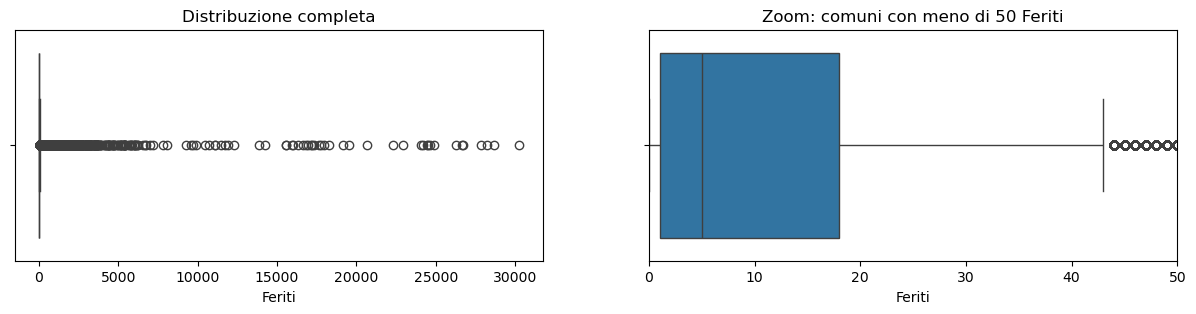

dal boxplot si vede come il 50% dei valori rientra in un range che va da [1.] a [18.] feriti, (IQR range). I baffi si estendono fino a 43.5 (Q3+1,5*IQR), i valori oltre sono outliers


In [101]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Feriti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Feriti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Feriti')

plt.show()

print(f'dal boxplot si vede come il 50% dei valori rientra in un range che va da {np.percentile(df['Feriti'],[25])} a {np.percentile(df['Feriti'],[75])} feriti, (IQR range). I baffi si estendono fino a 43.5 (Q3+1,5*IQR), i valori oltre sono outliers')

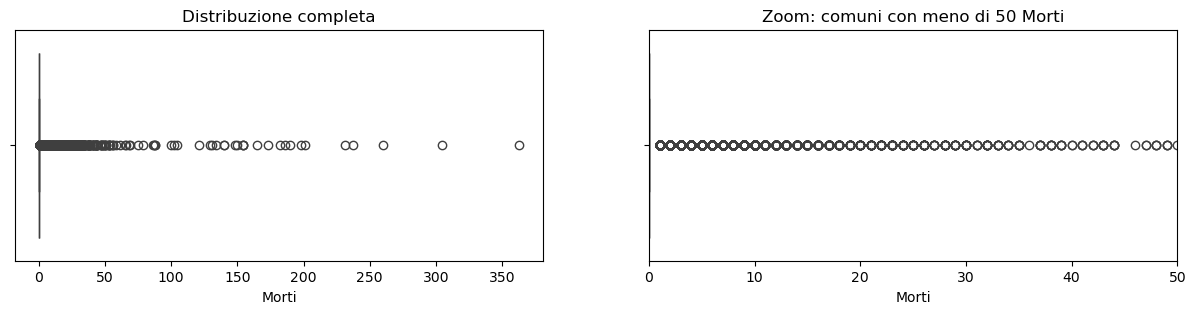

dal boxplot si vede come il 50% dei valori rientra in un range che va da [0.] a [0.] morti, (IQR range). Essendo 0 l IQR range, tutti i valori sono considerati outliers


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3))

sns.boxplot(x=df['Morti'], ax=axes[0])
axes[0].set_title('Distribuzione completa')
# zoom per poter vedere il boxplot, aggiungo soltanto la scala
sns.boxplot(x=df['Morti'], ax=axes[1])
axes[1].set_xlim(0, 50)
axes[1].set_title('Zoom: comuni con meno di 50 Morti')

plt.show()

print(f'dal boxplot si vede come il 50% dei valori rientra in un range che va da {np.percentile(df['Morti'],[25])} a {np.percentile(df['Morti'],[75])} morti, (IQR range). Essendo 0 l IQR range, tutti i valori sono considerati outliers')

### Istogramma 

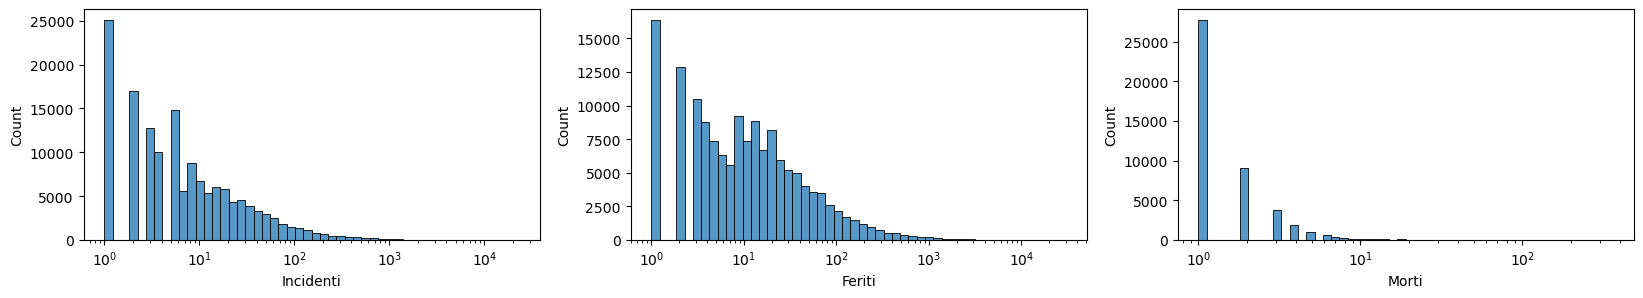

In [121]:
fig, axes = plt.subplots(1, 3, figsize=(20, 3))

sns.histplot(x='Incidenti', data=df, bins=50, ax=axes[0],log_scale=True)
sns.histplot(x='Feriti', data=df, bins=50, ax=axes[1],log_scale=True)
sns.histplot(x='Morti', data=df, bins=50, ax=axes[2],log_scale=True)
plt.show()

Incidenti: ha una skewed positiva, i valori sono più accoprtati a sinitra quindi la maggior parte dei comuni non ha molti incidenti all'anno. dove non ci sono colonne è perchè non ci sono dati/valori dentro a quel specifico range di incidenti
Feriti: ha una skewed positiva, in questo caso i valori sono distruibuiti verso destra. questo mi fa capire che, per logica, un incidente può causare più di un ferito e per questo vedo valori più alti
Morti: ha una skewed positiva, più marcata rispetto agli altri dati ma perchè i pochi valori che abbiamo si concentrano su un valore basso. i vuoti sono dovuti al fatto che sono eventi più rari e concentrati, quindi molti range non hanno dati.
Conclusione: il numero di incidenti sembra attenuarsi su valori bassi per la maggior parte dei comuni ma questo non implica meno feriti... ansi vedo che quelli hanno distribuzione maggiore per i vari range mentre per i morti sembrerebbe essere un evento più raro in italia.